
# **Load and Explore Data**

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve ,accuracy_score ,precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')



In [41]:
df = pd.read_csv("fraud_oracle.csv")
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())


Dataset Shape: (15420, 33)

First few rows:
  Month  WeekOfMonth  DayOfWeek    Make AccidentArea DayOfWeekClaimed  \
0   Dec            5  Wednesday   Honda        Urban          Tuesday   
1   Jan            3  Wednesday   Honda        Urban           Monday   
2   Oct            5     Friday   Honda        Urban         Thursday   
3   Jun            2   Saturday  Toyota        Rural           Friday   
4   Jan            5     Monday   Honda        Urban          Tuesday   

  MonthClaimed  WeekOfMonthClaimed     Sex MaritalStatus  ...  AgeOfVehicle  \
0          Jan                   1  Female        Single  ...       3 years   
1          Jan                   4    Male        Single  ...       6 years   
2          Nov                   2    Male       Married  ...       7 years   
3          Jul                   1    Male       Married  ...   more than 7   
4          Feb                   2  Female        Single  ...       5 years   

  AgeOfPolicyHolder PoliceReportFiled Witn

In [42]:
print("\nTarget Variable Distribution:")
print(df['FraudFound_P'].value_counts())
print(f"\nFraud Percentage: {(df['FraudFound_P'].sum() / len(df)) * 100:.2f}%")



Target Variable Distribution:
FraudFound_P
0    14497
1      923
Name: count, dtype: int64

Fraud Percentage: 5.99%


### Data Exploration & Analysis

In [44]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum().sum())

# Separate categorical and numerical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('FraudFound_P')  # Remove target variable

print(f"\nCategorical Columns: {len(cat_cols)}")
print(cat_cols)
print(f"\nNumerical Columns: {len(num_cols)}")
print(num_cols)

# Statistical summary for numerical columns
print("\nNumerical Summary:")
print(df[num_cols].describe())

# Check categorical columns unique values
print("\nCategorical Columns Unique Values:")
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")

Missing Values:
0

Categorical Columns: 24
['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'BasePolicy']

Numerical Columns: 8
['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Year']

Numerical Summary:
        WeekOfMonth  WeekOfMonthClaimed           Age  PolicyNumber  \
count  15420.000000        15420.000000  15420.000000  15420.000000   
mean       2.788586            2.693969     39.855707   7710.500000   
std        1.287585            1.259115     13.492377   4451.514911   
min        1.000000            1.000000      0.000000      1.000000   
25%        2.000000            2.000000     31.0000

### Data Preprocessing - Encoding Categorical Variables

In [45]:
# Create a copy for preprocessing
df_processed = df.copy()

# Encode categorical variables using LabelEncoder
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    le_dict[col] = le
    print(f"Encoded {col}: {len(le.classes_)} unique values")

# Check the processed data
print("\nProcessed Data:")
print(df_processed.head())
print("\nData Types After Encoding:")
print(df_processed.dtypes)

Encoded Month: 12 unique values
Encoded DayOfWeek: 7 unique values
Encoded Make: 19 unique values
Encoded AccidentArea: 2 unique values
Encoded DayOfWeekClaimed: 8 unique values
Encoded MonthClaimed: 13 unique values
Encoded Sex: 2 unique values
Encoded MaritalStatus: 4 unique values
Encoded Fault: 2 unique values
Encoded PolicyType: 9 unique values
Encoded VehicleCategory: 3 unique values
Encoded VehiclePrice: 6 unique values
Encoded Days_Policy_Accident: 5 unique values
Encoded Days_Policy_Claim: 4 unique values
Encoded PastNumberOfClaims: 4 unique values
Encoded AgeOfVehicle: 8 unique values
Encoded AgeOfPolicyHolder: 9 unique values
Encoded PoliceReportFiled: 2 unique values
Encoded WitnessPresent: 2 unique values
Encoded AgentType: 2 unique values
Encoded NumberOfSuppliments: 4 unique values
Encoded AddressChange_Claim: 5 unique values
Encoded NumberOfCars: 5 unique values
Encoded BasePolicy: 3 unique values

Processed Data:
   Month  WeekOfMonth  DayOfWeek  Make  AccidentArea  Da

### Correlation Heatmap

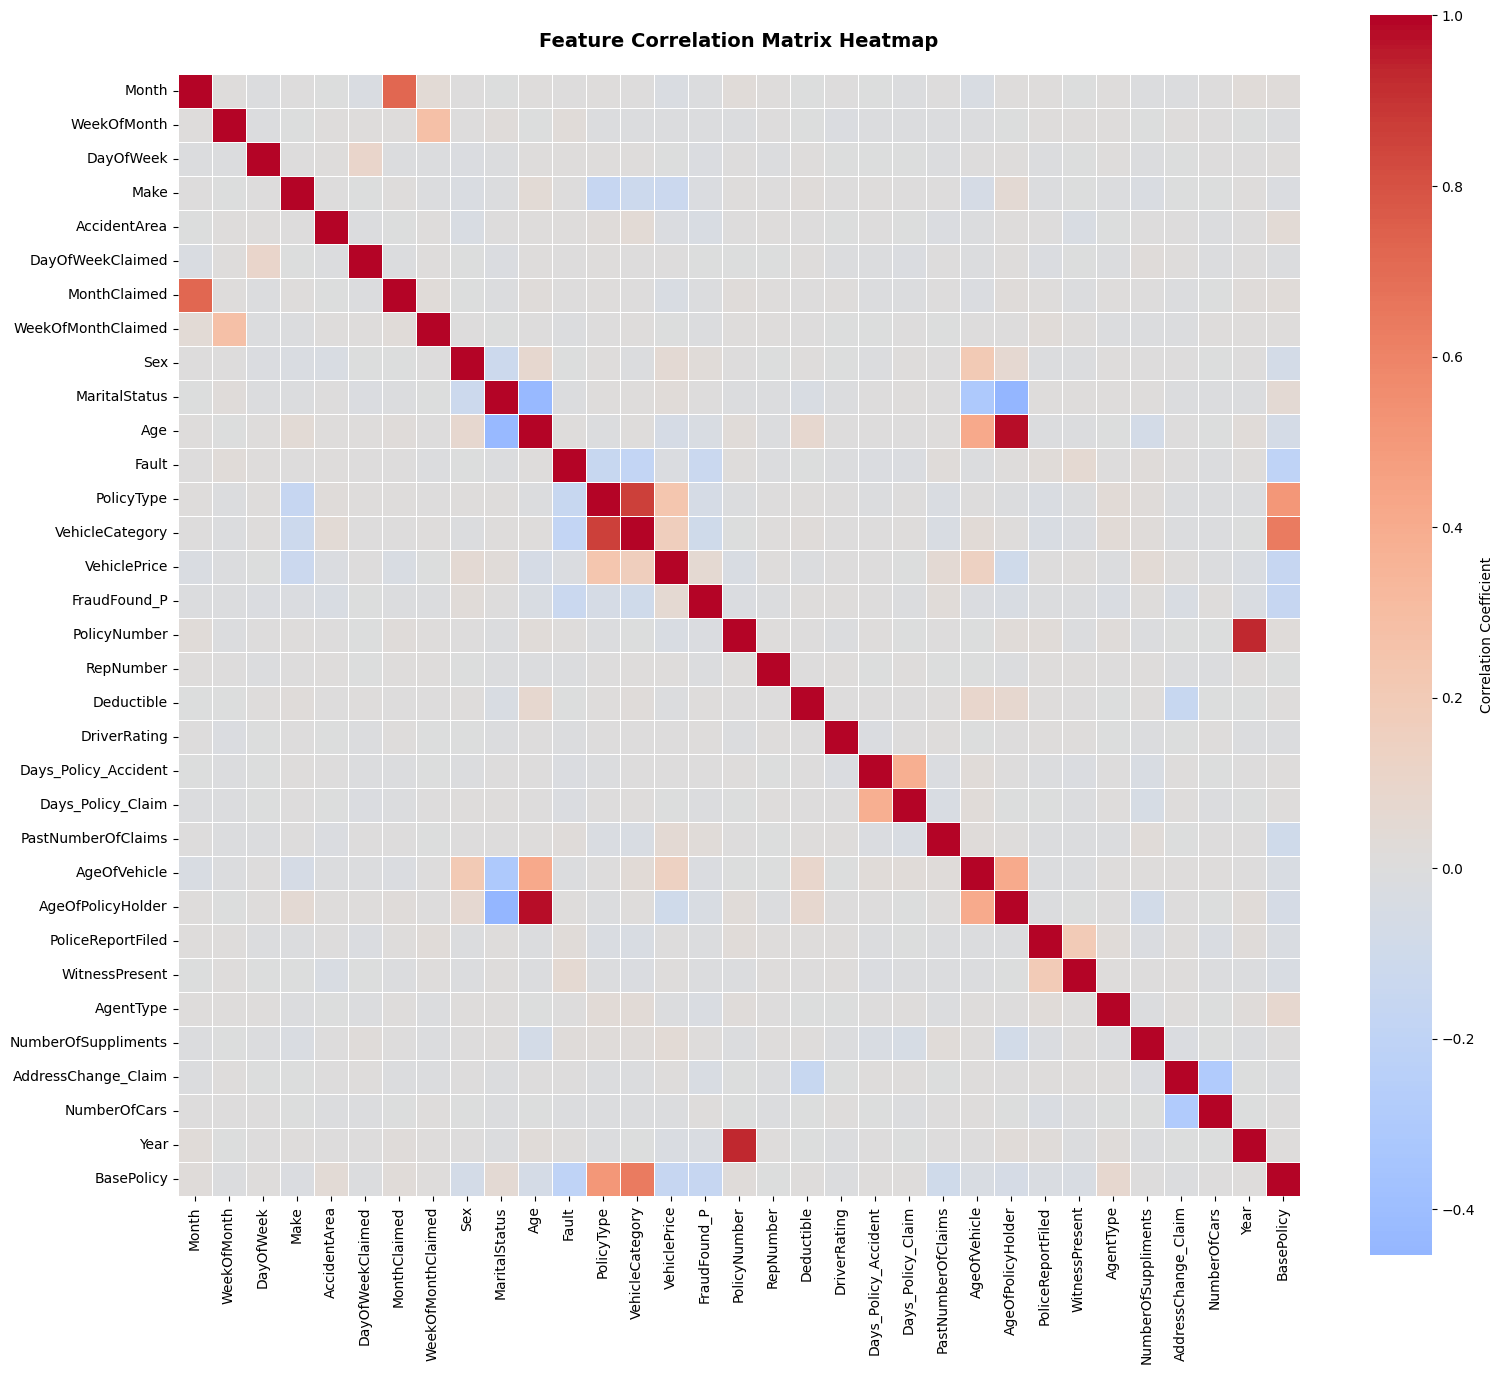

Correlation Heatmap saved as 'correlation_heatmap.png'
Correlation matrix shape: (33, 33)


In [46]:
# Calculate correlation matrix for numerical features
correlation_matrix = df_processed.corr()

# Create a large heatmap
fig, ax = plt.subplots(figsize=(16, 14))

# Create the heatmap
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'},
            ax=ax)

ax.set_title('Feature Correlation Matrix Heatmap', fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Correlation Heatmap saved as 'correlation_heatmap.png'")
print(f"Correlation matrix shape: {correlation_matrix.shape}")

### Feature Importance & Selection

In [47]:
# Separate features and target
X = df_processed.drop('FraudFound_P', axis=1)
y = df_processed['FraudFound_P']

# Split data for feature selection training
X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(X, y, test_size=0.2, 
                                                                          random_state=42, stratify=y)

# Train a preliminary Random Forest for feature selection
print("Training preliminary Random Forest for feature selection...")
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf_temp.fit(X_train_temp, y_train_temp)

# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_temp.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nAll Features with Importance Scores:")
print(feature_importance.to_string(index=False))

# Feature Selection - Select features with importance > threshold
IMPORTANCE_THRESHOLD = 0.01
selected_features = feature_importance[feature_importance['Importance'] > IMPORTANCE_THRESHOLD]['Feature'].tolist()

print(f"\n{'='*60}")
print(f"FEATURE SELECTION RESULTS")
print(f"{'='*60}")
print(f"Importance Threshold: {IMPORTANCE_THRESHOLD}")
print(f"Original number of features: {X.shape[1]}")
print(f"Selected number of features: {len(selected_features)}")
print(f"Reduction: {((X.shape[1] - len(selected_features)) / X.shape[1] * 100):.2f}%")
print(f"\nSelected Features:")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

Training preliminary Random Forest for feature selection...

All Features with Importance Scores:
             Feature  Importance
               Fault    0.121726
        PolicyNumber    0.097809
          BasePolicy    0.079730
                 Age    0.059422
           RepNumber    0.049990
          PolicyType    0.047051
               Month    0.046795
        MonthClaimed    0.046210
                Make    0.041499
           DayOfWeek    0.036104
    DayOfWeekClaimed    0.031821
     VehicleCategory    0.030407
        VehiclePrice    0.030315
         WeekOfMonth    0.028660
  WeekOfMonthClaimed    0.027861
        AgeOfVehicle    0.027209
        DriverRating    0.026816
  PastNumberOfClaims    0.024502
 AddressChange_Claim    0.023291
   AgeOfPolicyHolder    0.023213
 NumberOfSuppliments    0.022696
                Year    0.018783
          Deductible    0.016367
       MaritalStatus    0.009855
                 Sex    0.008172
        AccidentArea    0.007269
        Num

 ### Data Preparation with Selected Features

In [48]:
# Select features based on importance
X_selected = X[selected_features]

print(f"Features shape before selection: {X.shape}")
print(f"Features shape after selection: {X_selected.shape}")

# Split data with selected features
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, 
                                                      random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(f"\nTraining set fraud percentage: {(y_train.sum() / len(y_train)) * 100:.2f}%")
print(f"Testing set fraud percentage: {(y_test.sum() / len(y_test)) * 100:.2f}%")

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaling completed!")
print(f"Scaled training data shape: {X_train_scaled.shape}")
print(f"Scaled testing data shape: {X_test_scaled.shape}")

Features shape before selection: (15420, 32)
Features shape after selection: (15420, 23)

Training set size: (12336, 23)
Testing set size: (3084, 23)

Training set fraud percentage: 5.98%
Testing set fraud percentage: 6.00%

Scaling completed!
Scaled training data shape: (12336, 23)
Scaled testing data shape: (3084, 23)


### Train Random Forest Classifier

In [49]:
# Train Random Forest Classifier with selected features
print("Training Random Forest Classifier with selected features...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, 
                                   class_weight='balanced', n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("\n" + "="*60)
print("RANDOM FOREST CLASSIFIER - RESULTS")
print("="*60)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

Training Random Forest Classifier with selected features...

RANDOM FOREST CLASSIFIER - RESULTS
Accuracy: 0.9410
Precision: 1.0000
Recall: 0.0162
F1-Score: 0.0319
ROC-AUC: 0.8738

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       1.00      0.02      0.03       185

    accuracy                           0.94      3084
   macro avg       0.97      0.51      0.50      3084
weighted avg       0.94      0.94      0.91      3084


Confusion Matrix:
[[2899    0]
 [ 182    3]]


###  Feature Importance Heatmap from Final Model

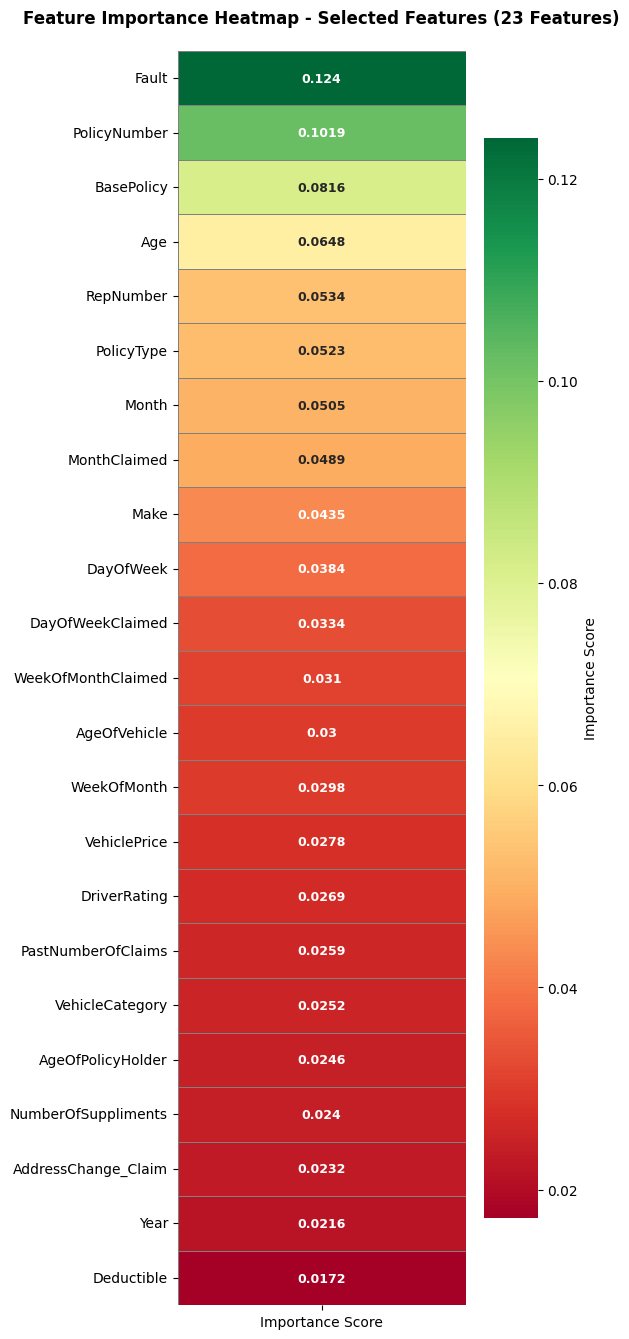

Feature Importance Heatmap saved as 'feature_importance_heatmap_selected.png'


In [50]:
# Get feature importance from the trained model
feature_importance_final = pd.DataFrame({
    'Feature': X_selected.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Reshape data for heatmap
heatmap_data = feature_importance_final['Importance'].values.reshape(-1, 1)

fig, ax = plt.subplots(figsize=(6, len(feature_importance_final)/2 + 2))

# Create the heatmap
sns.heatmap(heatmap_data, annot=feature_importance_final['Importance'].round(4).values.reshape(-1, 1),
            fmt='', cmap='RdYlGn', cbar_kws={'label': 'Importance Score'},
            yticklabels=feature_importance_final['Feature'].values,
            xticklabels=['Importance Score'], ax=ax, linewidths=0.5, linecolor='gray',
            annot_kws={'fontsize': 9, 'fontweight': 'bold'})

ax.set_title(f'Feature Importance Heatmap - Selected Features ({len(feature_importance_final)} Features)', 
             fontweight='bold', fontsize=12, pad=20)
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('feature_importance_heatmap_selected.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Feature Importance Heatmap saved as 'feature_importance_heatmap_selected.png'")

### Performance Metrics Visualization

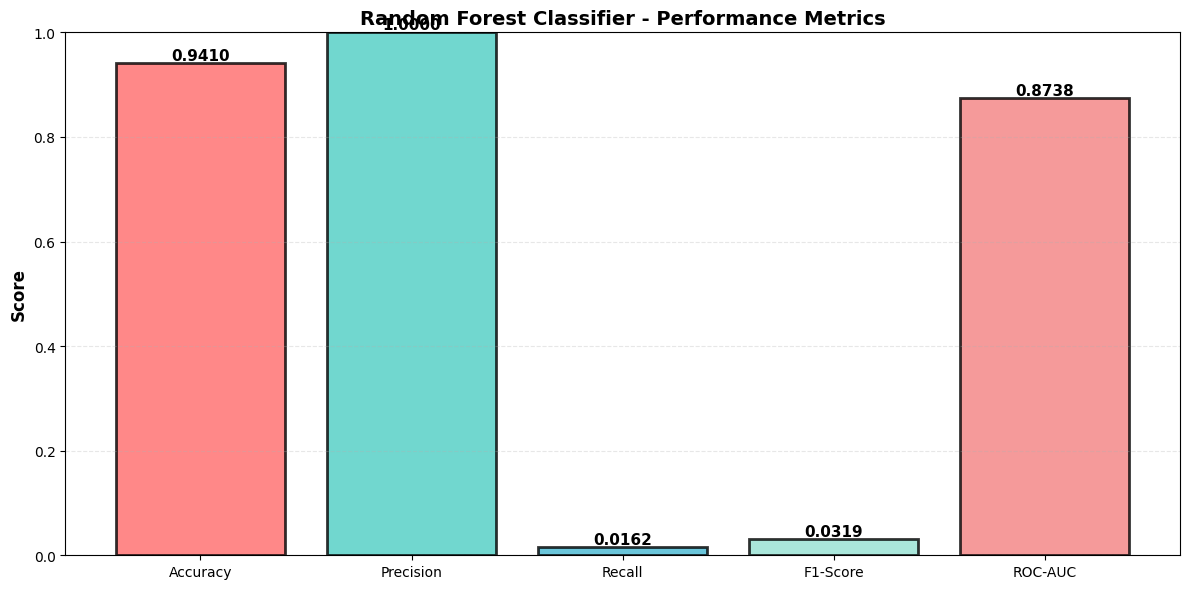

Performance Metrics chart saved as 'rf_metrics.png'


In [52]:
# Store metrics
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
}

# Visualize metrics
fig, ax = plt.subplots(figsize=(12, 6))

metrics_names = list(metrics.keys())
metrics_values = list(metrics.values())
colors_metrics = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#95E1D3', '#F38181']

bars = ax.bar(metrics_names, metrics_values, color=colors_metrics, alpha=0.8, 
              edgecolor='black', linewidth=2)
ax.set_ylabel('Score', fontweight='bold', fontsize=12)
ax.set_title('Random Forest Classifier - Performance Metrics', fontweight='bold', fontsize=14)
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('rf_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("Performance Metrics chart saved as 'rf_metrics.png'")

###  Confusion Matrix Heatmap

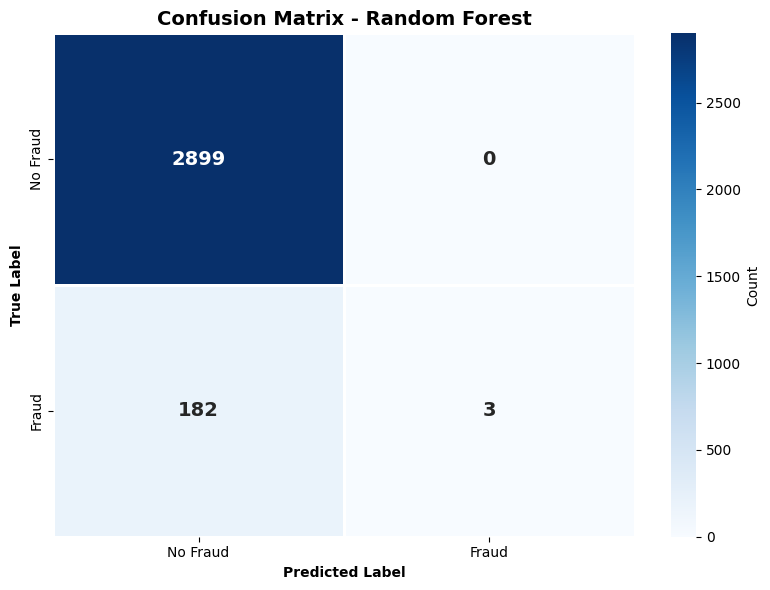

Confusion Matrix Heatmap saved as 'confusion_matrix_heatmap.png'


In [53]:
# Confusion matrix visualization
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=True,
            xticklabels=['No Fraud', 'Fraud'], yticklabels=['No Fraud', 'Fraud'],
            annot_kws={'fontsize': 14, 'fontweight': 'bold'},
            cbar_kws={'label': 'Count'}, linewidths=2, linecolor='white')

ax.set_title('Confusion Matrix - Random Forest', fontweight='bold', fontsize=14)
ax.set_ylabel('True Label', fontweight='bold')
ax.set_xlabel('Predicted Label', fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion Matrix Heatmap saved as 'confusion_matrix_heatmap.png'")

### ROC Curve

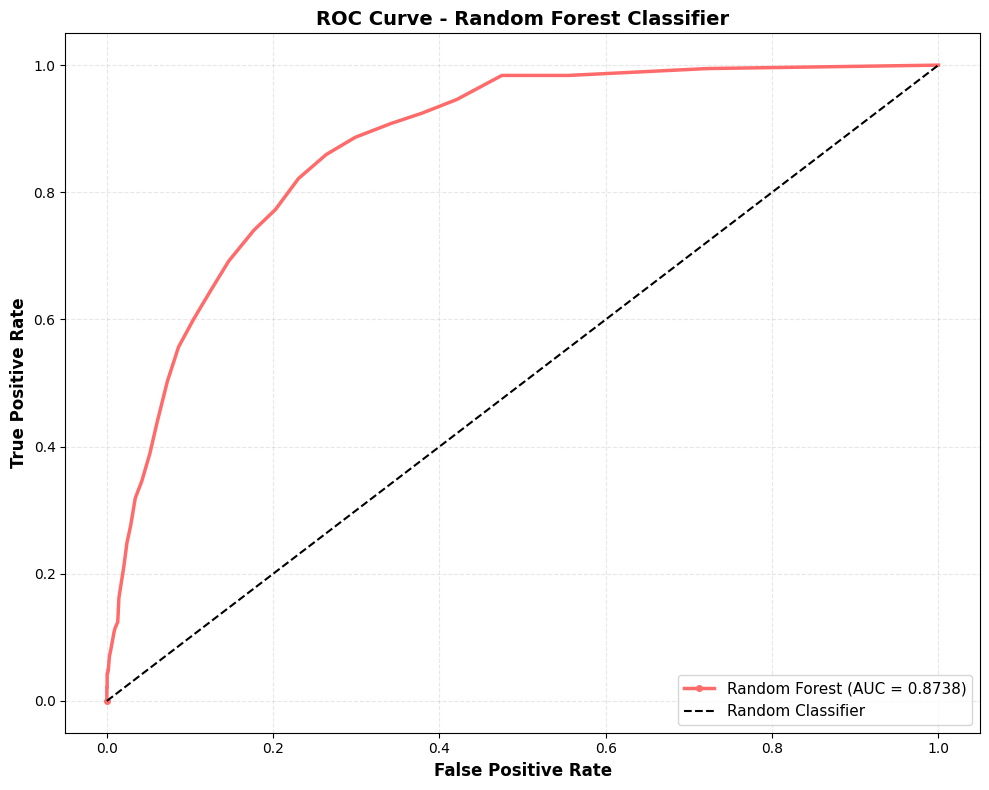

ROC Curve saved as 'roc_curve_rf.png'


In [54]:
# Plot ROC Curve
fig, ax = plt.subplots(figsize=(10, 8))

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.4f})', 
         linewidth=2.5, color='#FF6B6B', marker='o', markersize=4, markevery=50)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1.5)

plt.xlabel('False Positive Rate', fontweight='bold', fontsize=12)
plt.ylabel('True Positive Rate', fontweight='bold', fontsize=12)
plt.title('ROC Curve - Random Forest Classifier', fontweight='bold', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('roc_curve_rf.png', dpi=300, bbox_inches='tight')
plt.show()

print("ROC Curve saved as 'roc_curve_rf.png'")